## Module_3:

## Team Members:
Conner Looney and Jack Marchesi

## Project Title:
Fibrosis and Data Interpolation



## Project Goal:
This project seeks to gain a better understanding of the symptoms, mechanisms, and treatments for firbrosis while developing interpolation skills by analyising a set of data/images.

## Disease Background: 

**Prevalence & Incidence:**

Text here

**Risk Factors (genetic, lifestyle)**

Text here
**Symptoms**

Text here

**Standard of Care Treatment(s)**

Text here

**Biological Mechanisms (anatomy, organ physiology, cell & molecular physiology)**

Text here

## Data-Set: 
*Describe the data set(s) you will analyze. Cite the source(s) of the data -- in this case, these data have not yet been published and they are "hot off the press", having been recently generated by the Peirce-Cottler Lab in collaboration with the Kim Lab (https://uvahealth.com/findadoctor/John-Kim-1407155682) in the Division of Pulmonary and Critical Care at UVA. So the proper way to cite these data is:

"Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 

Also, since we covered this in Lecture 1 of this Module in detail, describe how the data was collected -- What techniques were used? What units are the data measured in? Etc.*

## Data Analyis: 
*Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this Jupyter notebook can run your code to perform the analysis that you did, generate your figures, generate your .csv file, etc.). Show your graphs here, which should have proper labeles (e.g., x- and y-axes labels). Each graph you present should be thoroughly described by a caption so reader understands the data, why you are presenting it, and the main conclusion fromt the data.*



Counts of pixel color in each image
C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010021.jpg

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010021.jpg:
White pixels: 23900
Black pixels: 4170404
0.57% White | Depth: 30 microns
C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010030.jpg

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010030.jpg:
White pixels: 37799
Black pixels: 4156505
0.90% White | Depth: 200 microns
C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010051.jpg

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010051.jpg:
White pixels: 43424
Black pixels: 4150880
1.04% White | Depth: 400 microns
C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\M

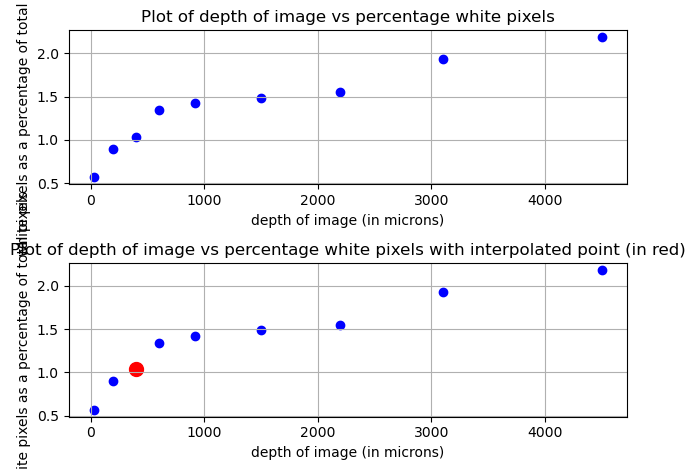

In [1]:
#AI Usage Statement: AI was used to help debug and increase efficiency

from termcolor import colored
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
import cv2
import numpy as np
import pandas as pd
import time

start_time = time.time()

filenames = [r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010021.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010030.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010051.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010024.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Slobe ch010158.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010067.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010164.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010174.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Slobe ch010134.jpg",
             ]
""""
filenames = [
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010021.jpg",
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010030.jpg",
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010051.jpg",
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010024.jpg",
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Slobe ch010158.jpg",
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010067.jpg",
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010164.jpg",
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010174.jpg",
    r"/Users/connerlooney/Documents/GitHub/Module-3-Fibrosis/images/MASK_Sk658 Slobe ch010134.jpg",
]
"""

depths = [30, 200, 400, 600, 920, 1500, 2200, 3100, 4500]

white_percents = []

print(colored("Counts of pixel color in each image", "yellow"))

for filename, depth in zip(filenames, depths):
    print(filename)
    img = cv2.imread(filename, 0)

    #if img is None:
     #   print(f"Error loading image: {filename}")
      #  continue

    # Threshold
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Count pixels efficiently
    white = np.count_nonzero(binary == 255)
    total = binary.size
    black = total - white

    # Compute percent
    white_percent = 100 * white / total
    white_percents.append(white_percent)

    # Print (same style as before)
    print(colored(f"\n{filename}:", "red"))
    print(colored(f"White pixels: {white}", "white"))
    print(colored(f"Black pixels: {black}", "grey"))
    print(f"{white_percent:.2f}% White | Depth: {depth} microns")

# Create DataFrame (UNCHANGED STRUCTURE)
df = pd.DataFrame({
    'Filenames': filenames,
    'Depths': depths,
    'White percents': white_percents
})

# Save CSV (same as before)
df.to_csv('Percent_White_Pixels.csv', index=False)

print("\nThe .csv file 'Percent_White_Pixels.csv' has been created.")


end_time = time.time()
print(f"\nExecution time: {end_time - start_time:.4f} seconds")


# LECTURE 2: UNCOMMENT BELOW

# # Interpolate a point: given a depth, find the corresponding white pixel percentage

interpolate_depth = float(input(colored(
     "Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))

x = depths
y = white_percents

 # You can also use 'quadratic', 'cubic', etc.
i = interp1d(x, y, kind='quadratic')
interpolate_point = i(interpolate_depth)
print(colored(
    f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)


# # make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a percentage of total pixels')
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o',
               linestyle='-', color='blue')
axs[1].set_title(
    'Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a percentage of total pixels')
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
               color='red', s=100, label='Highlighted point')


# # Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


First interpolation prediction using quadratic interpolation.

Counts of pixel color in each image

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010021.jpg:
White pixels: 23900
Black pixels: 4170404
0.57% White | Depth: 30 microns

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010030.jpg:
White pixels: 37799
Black pixels: 4156505
0.90% White | Depth: 200 microns

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010051.jpg:
White pixels: 43424
Black pixels: 4150880
1.04% White | Depth: 400 microns

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010024.jpg:
White pixels: 56360
Black pixels: 4137944
1.34% White | Depth: 600 microns

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Slobe ch010158.jpg:
White pixels: 59788
Black pixels: 4134516
1.43% White | Depth: 920 microns

C:\Users\Jmarc\Desktop\Comp BME\mo

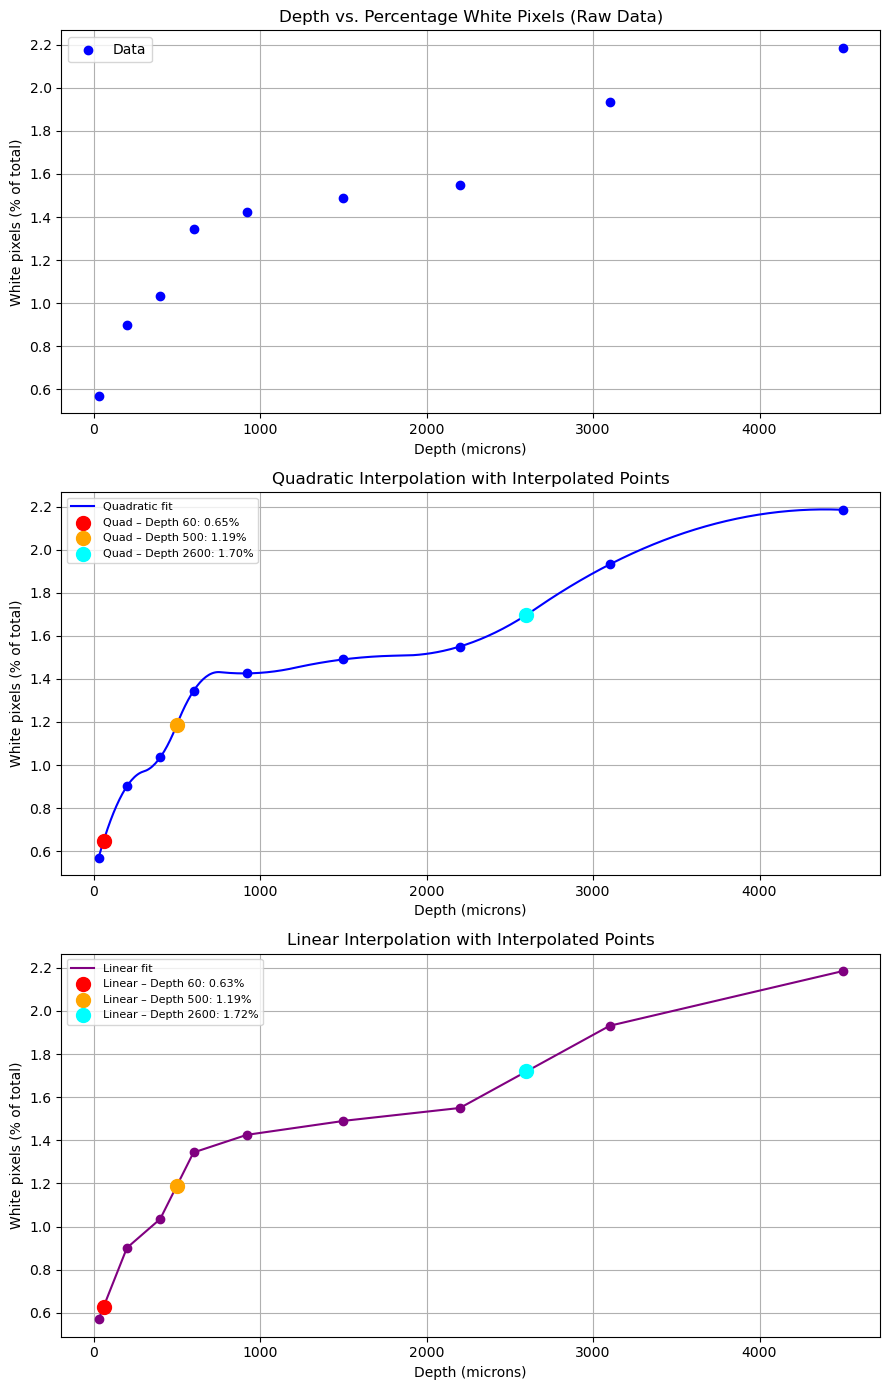


C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010019.jpg:
White pixels: 31331
Black pixels: 4162973
0.75% White | Depth: 60 microns

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010032.jpg:
White pixels: 48667
Black pixels: 4145637
1.16% White | Depth: 500 microns

C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010143.jpg:
White pixels: 70715
Black pixels: 4123589
1.69% White | Depth: 2600 microns

--- Percent Error vs. Ground Truth ---
Label              Depth      Actual        Quad   Quad Err%      Linear    Lin Err%
--------------------------------------------------------------------------------
Depth 60              60      0.7470      0.6479      13.26%      0.6283      15.89%
Depth 500            500      1.1603      1.1874       2.33%      1.1895       2.52%
Depth 2600          2600      1.6860      1.6972       0.67%      

In [3]:
#AI Usage Statement: AI was used to help debug and increase efficiency, as well as the plot functions

from termcolor import colored
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
import cv2
import numpy as np
import pandas as pd
import time


start_time = time.time()

filenames = [r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010021.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010030.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010051.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010024.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Slobe ch010158.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010067.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010164.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010174.jpg",
             r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Slobe ch010134.jpg",
             ]

# the depth in microns that each image was taken at
depths = [30, 200, 400, 600, 920, 1500, 2200, 3100, 4500]

# empty list to store the white pixel percentages as we calculate them
white_percents = []

print(colored("Counts of pixel color in each image", "yellow"))

# loop through each image and its corresponding depth at the same time
for filename, depth in zip(filenames, depths):
    # read the image in grayscale (0 flag = grayscale)
    img = cv2.imread(filename, 0)

    # convert grayscale to pure black and white using a threshold of 127
    # anything above 127 becomes 255 (white), anything below becomes 0 (black)
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # count the number of white pixels (value = 255)
    white = np.count_nonzero(binary == 255)
    # .size gives total number of pixels (rows * cols), NOT just rows
    total = binary.size
    # everything that isnt white must be black
    black = total - white

    # calculate what percent of the image is white
    white_percent = 100 * white / total
    white_percents.append(white_percent)

    # print the results for this image
    print(colored(f"\n{filename}:", "red"))
    print(colored(f"White pixels: {white}", "white"))
    print(colored(f"Black pixels: {black}", "grey"))
    print(f"{white_percent:.2f}% White | Depth: {depth} microns")

# store everything in a dataframe so we can save it as a csv
df = pd.DataFrame({
    'Filenames': filenames,
    'Depths': depths,
    'White percents': white_percents
})

# save the dataframe to a csv file
df.to_csv('Percent_White_Pixels.csv', index=False)
print("\nThe .csv file 'Percent_White_Pixels.csv' has been created.")

# stop the timer and print how long everything took
end_time = time.time()
print(f"\nExecution time: {end_time - start_time:.4f} seconds")

# Interpolation 

x = depths
y = white_percents

# create two interpolation functions using scipy - one quadratic, one linear
# these let us estimate white % at depths we didnt actually image
i_quadratic = interp1d(x, y, kind='quadratic')
i_linear    = interp1d(x, y, kind='linear')

# these are the three depths we want to predict - they match our ground truth images
query_depths = [60, 500, 2600]
query_labels = ['Depth 60', 'Depth 500', 'Depth 2600']

# run each "query" depth through both interpolators
quad_points   = [float(i_quadratic(d)) for d in query_depths]
linear_points = [float(i_linear(d))    for d in query_depths]

# print a nicely formatted table comparing the two methods
print(colored("\n--- Interpolation Results ---", "yellow"))
print(f"{'Label':<15} {'Depth':>8}  {'Quadratic':>12}  {'Linear':>12}")
print("-" * 52)
for lbl, d, q, l in zip(query_labels, query_depths, quad_points, linear_points):
    print(colored(f"{lbl:<15} {d:>8.1f}  {q:>12.4f}  {l:>12.4f}", "green"))

# Plots are below - they show the original data points, the interpolation curves, and the interpolated points for visual comparison

# generate 500 evenly spaced depth values across our range for smooth curve plotting
depth_smooth = np.linspace(min(x), max(x), 500)
curve_quad   = i_quadratic(depth_smooth)
curve_linear = i_linear(depth_smooth)

# colors for the interpolated points on the plots
point_colors = ['red', 'orange', 'cyan']

# 3 subplots stacked vertically
fig, axs = plt.subplots(3, 1, figsize=(9, 14))

# Plot 1: just the raw data, no interpolation ---
axs[0].scatter(x, y, marker='o', color='blue', zorder=5, label='Data')
axs[0].set_title('Depth vs. Percentage White Pixels (Raw Data)')
axs[0].set_xlabel('Depth (microns)')
axs[0].set_ylabel('White pixels (% of total)')
axs[0].grid(True)
axs[0].legend()

# Plot 2: quadratic curve + the interpolated points highlighted ---
axs[1].plot(depth_smooth, curve_quad, color='blue', linewidth=1.5, label='Quadratic fit')
axs[1].scatter(x, y, marker='o', color='blue', zorder=5)
for d, p, lbl, col in zip(query_depths, quad_points, query_labels, point_colors):
    axs[1].scatter(d, p, color=col, s=100, zorder=6, label=f'Quad – {lbl}: {p:.2f}%')
axs[1].set_title('Quadratic Interpolation with Interpolated Points')
axs[1].set_xlabel('Depth (microns)')
axs[1].set_ylabel('White pixels (% of total)')
axs[1].grid(True)
axs[1].legend(fontsize=8)

# --- Plot 3: linear curve + the interpolated points highlighted ---
axs[2].plot(depth_smooth, curve_linear, color='purple', linewidth=1.5, label='Linear fit')
axs[2].scatter(x, y, marker='o', color='purple', zorder=5)
for d, p, lbl, col in zip(query_depths, linear_points, query_labels, point_colors):
    axs[2].scatter(d, p, color=col, s=100, zorder=6, label=f'Linear – {lbl}: {p:.2f}%')
axs[2].set_title('Linear Interpolation with Interpolated Points')
axs[2].set_xlabel('Depth (microns)')
axs[2].set_ylabel('White pixels (% of total)')
axs[2].grid(True)
axs[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Verification of interpolation accuracy using true images
# these are the actual images taken at the depths we interpolated above
# we use them to check how accurate our interpolations were

after_filenames = [r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010019.jpg",
                   r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010032.jpg",
                   r"C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010143.jpg"]

after_depths = [60, 500, 2600]
after_white_percents = []

# Same pixel counting process as before, just for the after images
for filename, depth in zip(after_filenames, after_depths):
    img = cv2.imread(filename, 0)

    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    white = np.count_nonzero(binary == 255)
    total = binary.size
    black = total - white

    white_percent = 100 * white / total
    after_white_percents.append(white_percent)

    print(colored(f"\n{filename}:", "red"))
    print(colored(f"White pixels: {white}", "white"))
    print(colored(f"Black pixels: {black}", "grey"))
    print(f"{white_percent:.2f}% White | Depth: {depth} microns")

# Percent Error calculations
# percent error formula: |predicted - actual| / actual * 100
# this tells us how far off each interpolation method was from the real image

print(colored("\n--- Percent Error vs. Ground Truth ---", "yellow"))
print(f"{'Label':<15} {'Depth':>8}  {'Actual':>10}  {'Quad':>10}  {'Quad Err%':>10}  {'Linear':>10}  {'Lin Err%':>10}")
print("-" * 80)

quad_errors   = []
linear_errors = []

for lbl, d, actual, q, l in zip(query_labels, after_depths, after_white_percents, quad_points, linear_points):
    quad_err   = abs(q - actual) / actual * 100
    linear_err = abs(l - actual) / actual * 100
    quad_errors.append(quad_err)
    linear_errors.append(linear_err)
    print(colored(
        f"{lbl:<15} {d:>8}  {actual:>10.4f}  {q:>10.4f}  {quad_err:>9.2f}%  {l:>10.4f}  {linear_err:>9.2f}%",
        "green"))

# print the average error for each method so we can compare them overall
print("-" * 80)
print(colored(
    f"{'Mean Error':<15} {'':>8}  {'':>10}  {'':>10}  {np.mean(quad_errors):>9.2f}%  {'':>10}  {np.mean(linear_errors):>9.2f}%",
    "cyan"))

## Verify and validate your analysis: 
*Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., by comparing your analysis to a published paper).*

## Conclusions and Ethical Implications: 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

## References:
*You can use any format you like but provide the citations for facts that you referenced in this project notebook.*